In [ ]:
#Logistic Regression Assignments.
#Building a Logistic regression model using ML techniques with the Banking dataset’s.
#Name: Philip Kofi SIka Egyir
#Reg.No: SE/DAT/25/0016


In [7]:
#Setting my working directory
import os
os.chdir("C:/ML2026")


In [10]:
#importing my packages 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [11]:
plt.rc("font", size=14)
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [13]:
#Importing and inspecting my dataframe
bank_data = pd.read_csv("C:/ML2026/banking.csv")
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [14]:
# Dropping missing values and NA's
bank_data = bank_data.dropna()

In [15]:
#checking the shape of the new bank_data
bank_data.shape

(41188, 21)

In [16]:
#checking to see features in the dataframe
bank_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [17]:
#Viewing the first five obsebation of the dataframe.
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [18]:
#Viewing the education varaible to see the number of categories
bank_data["education"].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [19]:
#Renaming the category "basic.4y", "basic.6y" and "basic.9y" to "Basic"
bank_data["education"]=np.where(bank_data["education"]=="basic.4y","Basic",bank_data["education"])
bank_data["education"]=np.where(bank_data["education"]=="basic.6y","Basic",bank_data["education"])
bank_data["education"]=np.where(bank_data["education"]=="basic.9y","Basic",bank_data["education"])

In [20]:
#Viewing to see if the renaming has been effected
bank_data["education"].unique()

array(['Basic', 'unknown', 'university.degree', 'high.school',
       'professional.course', 'illiterate'], dtype=object)

In [21]:
#Exploring the data for analysis
bank_data["y"].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

C:\Users\kofis\AppData\Local\Temp\ipykernel_23496\391191755.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y", data=bank_data, palette="hls")


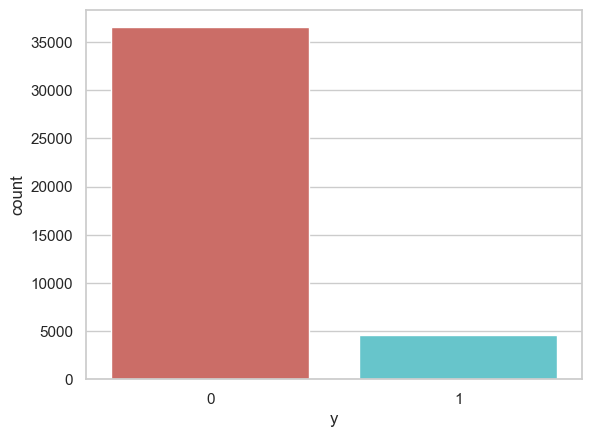

In [28]:
#Drawing a count plot for the variable y in the bank_data.
sns.countplot(x="y", data=bank_data, palette="hls")
plt.show()

Using matplotlib backend: module://matplotlib_inline.backend_inline


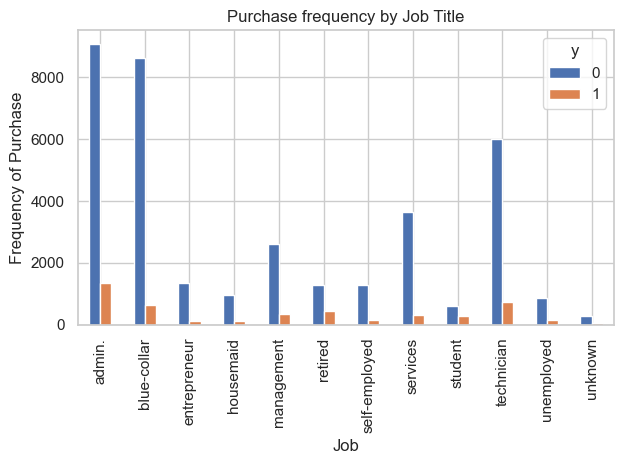

In [29]:
#Visualization of the dataset
#Comparing customers’ job types with whether they subscribed to the bank product or not.
%matplotlib
pd.crosstab(bank_data.job,bank_data.y).plot(kind="bar")
plt.title("Purchase frequency by Job Title")
plt.xlabel("Job")
plt.ylabel("Frequency of Purchase")
plt.tight_layout()

Text(0, 0.5, 'Proportion of customers')

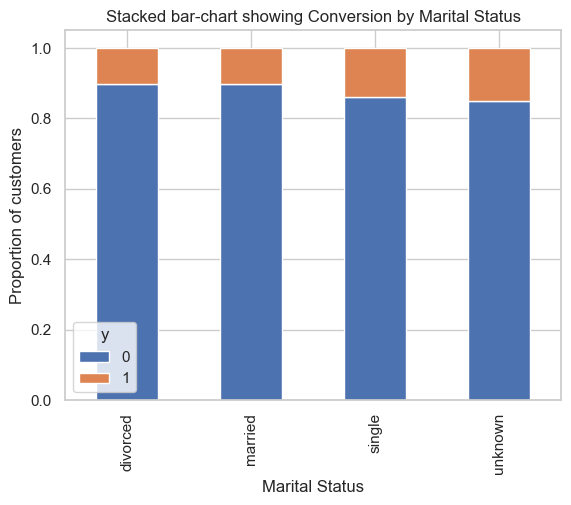

In [30]:
#showing the proportion of customers who subscribed or did not subscribe to the bank product, grouped by marital status.
table = pd.crosstab(bank_data.marital, bank_data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.title("Stacked bar-chart showing Conversion by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Proportion of customers")


Text(0, 0.5, 'Proportion of customers')

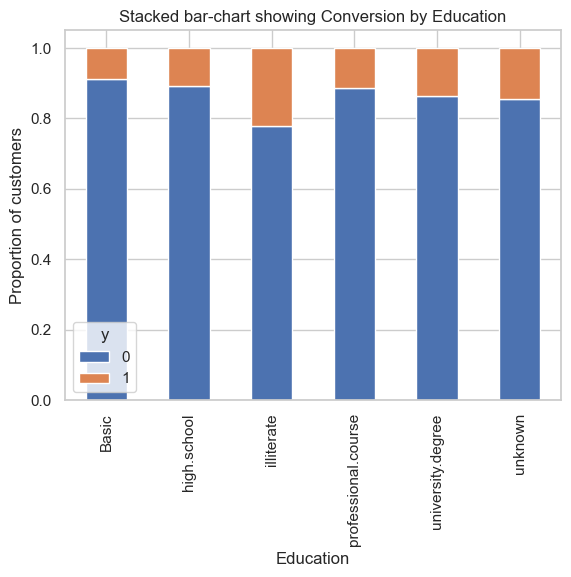

In [31]:
#showing how customers’ education levels are related to whether they subscribed to the bank product or not.
table = pd.crosstab(bank_data.education, bank_data.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.title("Stacked bar-chart showing Conversion by Education")
plt.xlabel("Education")
plt.ylabel("Proportion of customers")

Text(0, 0.5, 'Frequency of purchase')

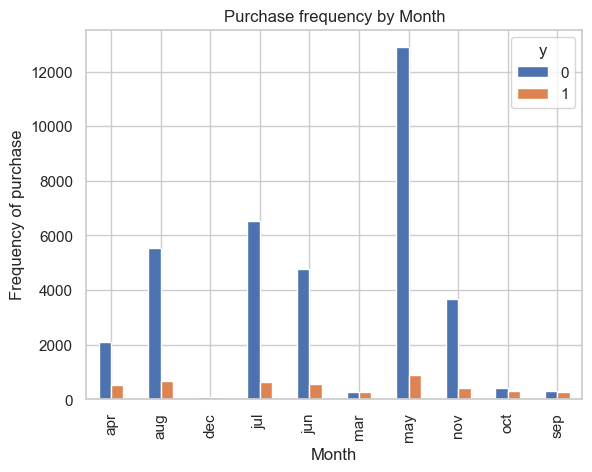

In [32]:
#showing how customer subscription differs by month.
pd.crosstab(bank_data.month, bank_data.y).plot(kind="bar")
plt.title("Purchase frequency by Month")
plt.xlabel("Month")
plt.ylabel("Frequency of purchase")

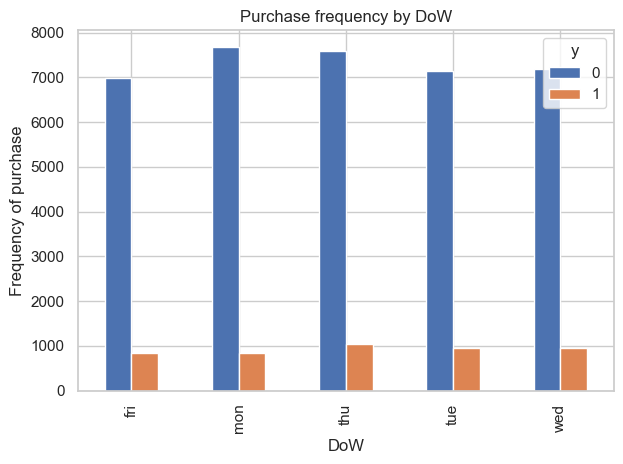

In [33]:
#showing how customer subscription differs by day of the week.
pd.crosstab(bank_data.day_of_week, bank_data.y).plot(kind='bar')
plt.title("Purchase frequency by DoW")
plt.xlabel("DoW")
plt.ylabel("Frequency of purchase")
plt.tight_layout()

In [39]:
#trying to convert categorical variables into dummy variables
categorical_variable_cols = ["job","marital","education","default","housing","loan",
                             "contact","month","day_of_week","poutcome"]
for var in categorical_variable_cols:
    categ_list = "var_" + var
    categ_list = pd.get_dummies(bank_data[var], prefix=var)
    bank_data1 = bank_data.join(categ_list)
    bank_data = bank_data1
    
#NB
#I mistaken runned this code twice that is why I'm getting this error
#I already created the dummy columns
#Running it for the second time it will throw this error. so please ignore the error.

ValueError: columns overlap but no suffix specified: Index(['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown'],
      dtype='object')

In [42]:
#creating a list of columns to keep after dummy variables have been created.
bank_data_vars = bank_data.columns.values.tolist()
to_keep = [i for i in bank_data_vars if i not in categorical_variable_cols]

In [43]:
#creating the final modelling dataset and then display its column names.
bank_data_final = bank_data[to_keep]
bank_data_final.columns.values

array(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student',
       'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_Basic', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_no',
       'default_unknown', 'default_yes', 'housing_no', 'housing_unknown',
       'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri',

In [44]:
#separating the target variable from the independent variables before modelling.
bank_data_final_vars = bank_data_final.columns.values.tolist()
y = ["y"]
X = [i for i in bank_data_final_vars if i not in y]

In [45]:
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

#selecting the best 18 predictor variables from the dataset
logreg = LogisticRegression()

rfe = RFE(logreg, n_features_to_select=18)

rfe = rfe.fit(bank_data_final[X], bank_data_final[y])

Selected_Features_Support = list(rfe.support_)
Selected_Features_rank = list(rfe.ranking_)

print(Selected_Features_Support)
print(Selected_Features_rank)

C:\Users\kofis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\kofis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kofis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example us

[False, False, False, False, True, False, False, False, True, False, False, True, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, True, True, True, False, False, True, True, True, True, False, False, True, False, False, False, True, True, True]
[33, 31, 11, 37, 1, 14, 20, 16, 1, 30, 29, 1, 5, 38, 39, 1, 40, 2, 1, 19, 25, 42, 32, 28, 12, 43, 22, 18, 41, 23, 7, 3, 10, 1, 44, 36, 34, 21, 13, 35, 24, 1, 17, 1, 1, 1, 6, 15, 1, 1, 1, 1, 26, 27, 1, 9, 8, 4, 1, 1, 1]


C:\Users\kofis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\kofis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [46]:
#creating the final independent variables and target variable for the logistic regression model
columns_final = ["previous", "euribor3m", "job_blue-collar", "job_retired", 
                 "job_services", "job_student", "default_no", "month_aug", 
                 "month_dec", "month_jul", "month_nov", "month_oct", 
                 "month_sep", "day_of_week_fri", "day_of_week_wed", 
                 "poutcome_failure", "poutcome_nonexistent", "poutcome_success"] 

X = bank_data_final[columns_final]
y = bank_data_final["y"]

In [47]:
#splitting the data into training and testing sets, then train a logistic regression model.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [48]:
#Training the Model
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression()

logreg.fit(X_train, y_train)

LogisticRegression()

In [49]:
# Predicting the test set results and checking the accuracy
y_pred = logreg.predict(X_test)



In [50]:
#Calculating the accuracy
print('Accuracy of logistic regression classifier on test set: {:2f}'.format(logreg.score(X_test,y_test)))


Accuracy of logistic regression classifier on test set: 0.900299


In [51]:
#trying to evaluate the logistic regression model using 10-fold cross-validation.
from sklearn import model_selection
from sklearn.model_selection import cross_val_score

kfold = model_selection.KFold(n_splits=10, random_state=7, shuffle=True)

modelCV = LogisticRegression()

scoring = 'accuracy'

results = model_selection.cross_val_score(
    modelCV, X_train, y_train, cv=kfold, scoring=scoring
)

print("10-fold cross-validation average accuracy : %.3f" % (results.mean()))

10-fold cross-validation average accuracy : 0.897


In [53]:
#creating and print a confusion matrix for the model.
from sklearn.metrics import confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_pred)

print(confusion_matrix)

[[10872   109]
 [ 1123   253]]


In [54]:
#printing a detailed performance report for the classification model.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10981
           1       0.70      0.18      0.29      1376

    accuracy                           0.90     12357
   macro avg       0.80      0.59      0.62     12357
weighted avg       0.88      0.90      0.87     12357



In [ ]:
#My Final Report on the Model
#The logistic regression model was evaluated using a classification report on the test dataset, 
#and the results indicate strong but imbalanced predictive performance.
#The model achieved an overall accuracy of 0.90, meaning it correctly classified approximately 90% of all observations. 
#However, this high accuracy is largely influenced by the distribution of the target variable, 
#which is heavily skewed toward class 0 (non-subscribers).
#For class 0 (customers who did not subscribe), the model performed exceptionally well. 
#It recorded a precision of 0.91 and a recall of 0.99, with an F1-score of 0.95. 
#This indicates that the model is highly effective at correctly identifying non-subscribing customers, 
#and very few actual non-subscribers were misclassified.
#In contrast, the performance for class 1 (customers who subscribed) is considerably weaker. 
#Although the model achieved a precision of 0.70, meaning that 70% of predicted subscribers were correctly identified, 
#the recall is only 0.18, indicating that the model was able to detect only 18% of all actual subscribers. 
#The resulting F1-score of 0.29 reflects poor balance between precision and recall for this class.
#The macro average F1-score of 0.62 further confirms that the model’s performance is uneven across classes, 
#as it treats both classes equally and highlights the poor performance on the minority class. On the other hand, 
#the weighted average F1-score of 0.87 is higher because it is dominated by the majority class (class 0), which the model predicts very well.
#Overall, while the model demonstrates strong predictive ability for non-subscribers, it performs poorly in identifying actual subscribers. 
#This suggests that the model is biased toward the majority class and is not yet suitable for reliably detecting potential customers who will subscribe. 

